In [ ]:

import numpy as np

import torchcvnn.nn as c_nn

import torch
import torch.nn as nn

import torch.optim as optim

from tqdm import tqdm

import matplotlib.pyplot as plt
import math

In [20]:
activations_to_test = ["modrelu", "zrelu", "cardioid", "c_relu"]

In [11]:
def get_complex_activation(name: str):
    name = name.lower()
    if name == "modrelu":
        return c_nn.modReLU()
    elif name == "zrelu":
        return c_nn.zReLU()
    elif name == "cardioid":
        return c_nn.Cardioid()
    elif name == "c_relu":
        return c_nn.CReLU()
    else:
        return nn.Identity()

In [22]:
device = "cpu"

#### Singularities

In [21]:
def f_inv_t(z):        return 1.0 / z
def f_tan_t(z):        return torch.tan(z)
def f_multi_pole_t(z): return 1.0 / (z * (z - 1.0) * (z + 1.0))
def f_exp_ess_t(z):    return torch.exp(1.0 / z)
def f_sin_osc_t(z):    return torch.sin(1.0 / z)


In [24]:
singl_fcns = {
    "1/z": f_inv_t,
    "tan(z)": f_tan_t,
    "multi_pole": f_multi_pole_t,
    "exp(1/z)": f_exp_ess_t,
    "sin(1/z)": f_sin_osc_t,
}

In [25]:
def line_sweep(start, end, n=2000):
    t = np.linspace(0, 1, n)
    return start + (end - start) * t

def annulus_sweep(center=0+0j, radius=0.1, n=2000):
    theta = np.linspace(-np.pi, np.pi, n)
    return center + radius * np.exp(1j * theta)

In [37]:
def monitor(z, y, name="", blow_thresh=1e6):
    mag = y.abs()
    ph  = torch.angle(y)

    finite = torch.isfinite(mag)
    blow = (~finite) | (mag > blow_thresh)

    if finite.any():
        mag_finite = mag[finite]
        mag_min = mag_finite.min().item()
        mag_med = mag_finite.median().item()
        mag_max = mag_finite.max().item()
    else:
        mag_min = float("nan")
        mag_med = float("nan")
        mag_max = float("nan")

    num_blow = int(blow.sum().item())

    first_blow_idx = None
    if blow.any():
        first_blow_idx = int(torch.where(blow)[0][0].item())

    phase_jumps = (torch.abs(ph[1:] - ph[:-1]) > torch.pi).sum().item()

    return {
        "name": name,
        "mag_min": mag_min,
        "mag_med": mag_med,
        "mag_max": mag_max,
        "num_blow": num_blow,
        "first_blow_idx": first_blow_idx,
        "phase_jump_count": int(phase_jumps),
    }

In [38]:
z = line_sweep(start=-1-1j, end=1+1j, n=4000)

z = z + 1e-6*(1+1j)

z_t = torch.from_numpy(z).to(torch.complex64).to(device)

In [39]:
results = []
for fname, f in singl_fcns.items():
    y_t = f(z_t)
    results.append(monitor(z_t, y_t, name=f"{fname}"))

    for ac_fcn in activations_to_test:
        act = get_complex_activation(ac_fcn)
        ya = act(y_t)
        results.append(monitor(z_t, ya, name=f"{ac_fcn}({fname})"))

In [40]:
for r in results:
    print(r["name"], "| mag_med:", r["mag_med"], "| mag_max:", r["mag_max"],
          "| blow:", r["num_blow"], "| phase_jumps:", r["phase_jump_count"])

1/z | mag_med: 1.413156270980835 | mag_max: 2839.073486328125 | blow: 0 | phase_jumps: 0
modrelu(1/z) | mag_med: 1.413156270980835 | mag_max: 2839.073486328125 | blow: 0 | phase_jumps: 0
zrelu(1/z) | mag_med: 0.0 | mag_max: 0.0 | blow: 0 | phase_jumps: 0
cardioid(1/z) | mag_med: 0.7067663669586182 | mag_max: 2403.99658203125 | blow: 0 | phase_jumps: 0
c_relu(1/z) | mag_med: 0.9992523789405823 | mag_max: 2007.528076171875 | blow: 0 | phase_jumps: 0
tan(z) | mag_med: 0.6936144828796387 | mag_max: 1.1174705028533936 | blow: 0 | phase_jumps: 0
modrelu(tan(z)) | mag_med: 0.6936144828796387 | mag_max: 1.1174705028533936 | blow: 0 | phase_jumps: 0
zrelu(tan(z)) | mag_med: 0.0 | mag_max: 1.1174705028533936 | blow: 0 | phase_jumps: 0
cardioid(tan(z)) | mag_med: 0.285075843334198 | mag_max: 0.7076261043548584 | blow: 0 | phase_jumps: 0
c_relu(tan(z)) | mag_med: 0.0 | mag_max: 1.1174705028533936 | blow: 0 | phase_jumps: 0
multi_pole | mag_med: 1.2635868787765503 | mag_max: 2839.07373046875 | blow

In [55]:

def plot_mag_phase(z, y, title):
    y_np = y.detach().cpu().numpy()

    mag = np.abs(y_np)
    ph  = np.angle(y_np)

    plt.figure()
    plt.plot(mag)
    plt.yscale("log")
    plt.title(title + " | magnitude (log)")
    plt.xlabel("sweep index")
    plt.ylabel("|y|")
    plt.show()

    plt.figure()
    plt.plot(ph)
    plt.title(title + " | phase")
    plt.xlabel("sweep index")
    plt.ylabel("arg(y)")
    plt.show()

# # Example: sin(1/z) then modReLU
# y = f_sin_osc(z)
# plot_mag_phase(z, y, "sin(1/z)")

# ya = modrelu(y, b=0.0)
# plot_mag_phase(z, ya, "modReLU(sin(1/z))")


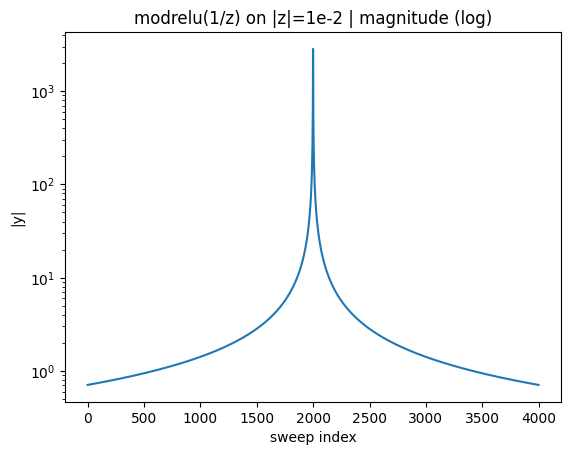

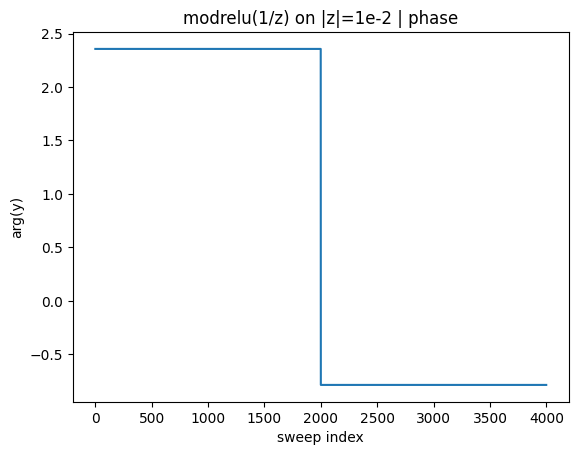

/tmp/ipykernel_3967/2138095970.py:9: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale("log")


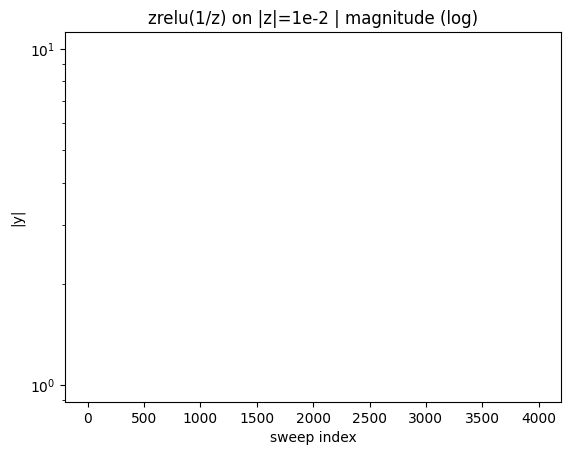

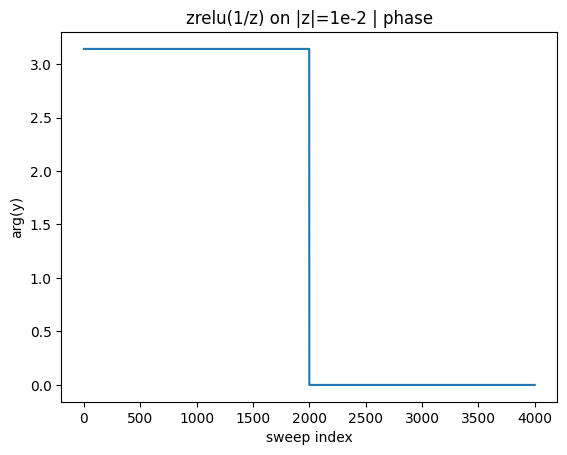

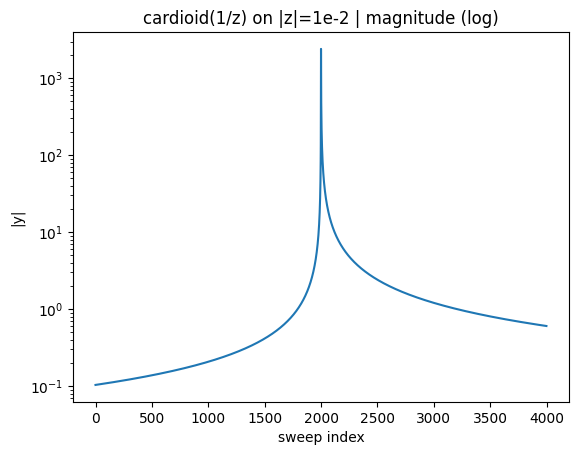

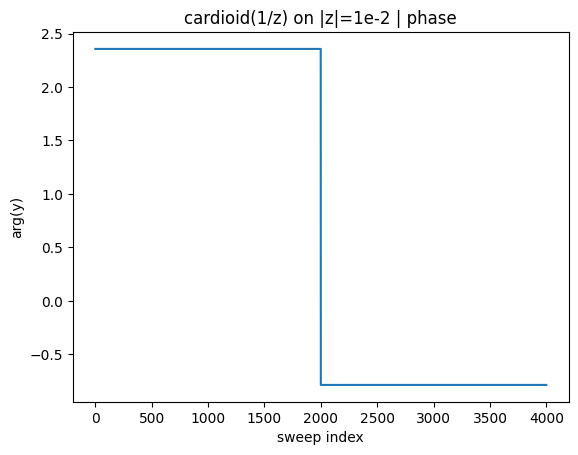

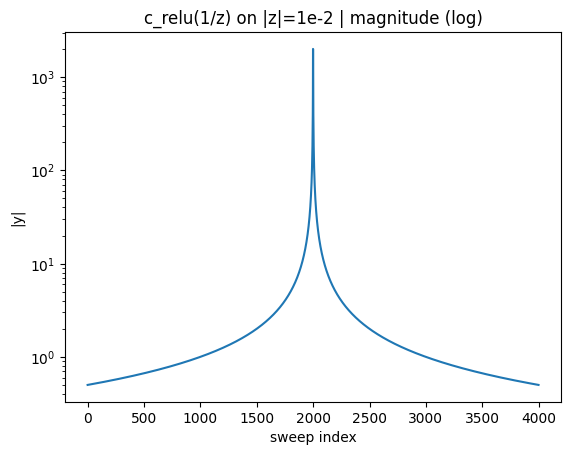

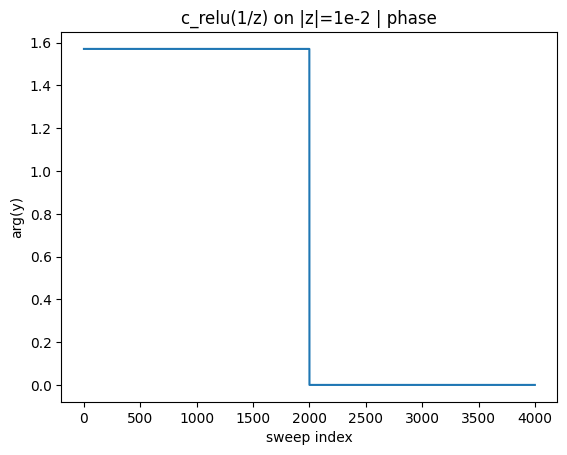

In [57]:
z = annulus_sweep(center=0+0j, radius=1e-2, n=4000)
y = f_inv_t(z_t)  # try 1/z, exp(1/z), sin(1/z)
for ac_fcn in activations_to_test:
    act = get_complex_activation(ac_fcn)
    ya = act(y)
    plot_mag_phase(z, ya, f"{ac_fcn}(1/z) on |z|=1e-2")

In [58]:
act = c_nn.modReLU()
print(act)
print("Parameters:", list(act.parameters()))

modReLU()
Parameters: [Parameter containing:
tensor(0., requires_grad=True)]


## Learning with Singularities

In [ ]:



# ---- device ----
device = "cpu"

# ---- singular functions (torch) ----
def f_inv(z):
    return 1.0 / z

def f_exp_ess(z):
    return torch.exp(1.0 / z)

def f_sin_osc(z):
    return torch.sin(1.0 / z)

SING_FUNCS = {
    "1/z": f_inv,
    "exp(1/z)": f_exp_ess,
    "sin(1/z)": f_sin_osc,
}

# ---- load your torchcvnn activations ----
# assumes your helper returns an nn.Module that maps complex->complex
# e.g., from torchcvnn.nn.modules.activation import modReLU, zReLU, cardioid, cReLU ...
# and get_complex_activation(name) returns module instances

# Placeholder: replace with your actual function
def get_complex_activation(name):
    import torchcvnn.nn as c_nn
    # adjust names to match your setup
    if name.lower() == "modrelu":
        return c_nn.modReLU()      # if your version uses c_nn.modReLU
    if name.lower() == "zrelu":
        return c_nn.zReLU()
    if name.lower() == "cardioid":
        return c_nn.Cardioid()
    if name.lower() in ["crelu", "c_relu", "c-relu"]:
        return c_nn.cReLU()
    raise ValueError(name)

activations_to_test = ["modReLU", "zReLU", "cReLU", "Cardioid"]

# ---- loss ----
def complex_mse(pred, target):
    # returns real scalar
    diff = pred - target
    return (diff.real**2 + diff.imag**2).mean()

# ---- training loop on a learnable complex parameter z ----
def run_escape_experiment(
    f_name="1/z",
    act_name="modReLU",
    lr=1e-2,
    steps=500,
    z0=1e-3 + 1e-3j,          # start near pole at 0
    y_target=1.0 + 0.0j,      # safe target
    mitigation=None,
    eps=1e-6,
    grad_clip=None,
    rmin=None,
    seed=0
):
    torch.manual_seed(seed)

    f = SING_FUNCS[f_name]
    act = get_complex_activation(act_name).to(device)

    # learnable complex parameter
    z = torch.tensor([z0], dtype=torch.complex64, device=device, requires_grad=True)

    opt = torch.optim.Adam([z], lr=lr)

    hist = {"loss": [], "r": [], "grad": [], "finite": []}

    y_star = torch.tensor([y_target], dtype=torch.complex64, device=device)

    for t in range(steps):
        opt.zero_grad(set_to_none=True)

        # --- mitigation hooks ---
        z_eff = z

        # (A) constraint: keep away from pole by projecting |z| >= rmin
        # projection happens after step, but we can also compute z_eff
        # for now z_eff = z

        # compute singular mapping (optionally "safe")
        if mitigation == "safe_inverse" and f_name == "1/z":
            y = 1.0 / (z_eff + eps)
        elif mitigation == "safe_essentials" and f_name in ["exp(1/z)", "sin(1/z)"]:
            # soften only the singular denominator
            y = f(1.0 / (z_eff + eps))  # equivalent to exp(1/(z+eps)) etc
        else:
            y = f(z_eff)

        # activation applied
        a = act(y)

        loss = complex_mse(a, y_star)

        # backprop
        loss.backward()

        # log gradient norm
        with torch.no_grad():
            g = z.grad
            gnorm = float(torch.sqrt(g.real**2 + g.imag**2).item()) if g is not None else float("nan")
            r = float(torch.abs(z).item())
            finite = torch.isfinite(loss).item() and torch.isfinite(torch.tensor(gnorm)).item()

        # gradient clipping
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_([z], max_norm=grad_clip)

        # optimizer step
        opt.step()

        # projection to enforce |z| >= rmin (simple pole-avoid constraint)
        if rmin is not None:
            with torch.no_grad():
                r_now = torch.abs(z)
                if r_now < rmin:
                    z.mul_(rmin / (r_now + 1e-12))

        # record
        hist["loss"].append(float(loss.detach().cpu().item()) if torch.isfinite(loss) else float("inf"))
        hist["r"].append(r)
        hist["grad"].append(gnorm)
        hist["finite"].append(bool(finite))

        # early stop on NaN/Inf
        if not finite:
            break

    return hist

# ---- plot helper ----
def plot_hist(hist, title):
    loss = hist["loss"]
    r    = hist["r"]
    grad = hist["grad"]

    plt.figure()
    plt.plot(loss)
    plt.yscale("log")
    plt.title(title + " | loss (log)")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.show()

    plt.figure()
    plt.plot(r)
    plt.yscale("log")
    plt.title(title + " | |z| distance-to-pole (log)")
    plt.xlabel("step")
    plt.ylabel("|z|")
    plt.show()

    plt.figure()
    plt.plot(grad)
    plt.yscale("log")
    plt.title(title + " | grad norm (log)")
    plt.xlabel("step")
    plt.ylabel("||∇z L||")
    plt.show()


In [ ]:
hist_bad = run_escape_experiment(
    f_name="1/z",
    act_name="modReLU",
    lr=1e-2,
    steps=500,
    z0=1e-6 + 1e-6j,     # extremely close to pole
    y_target=1.0+0j,
    mitigation=None,     # no safeguards
    grad_clip=None,
    rmin=None
)
plot_hist(hist_bad, "BAD: 1/z + modReLU, no mitigation, start near pole")


In [ ]:
hist_safe = run_escape_experiment(
    f_name="1/z",
    act_name="modReLU",
    lr=1e-2,
    steps=500,
    z0=1e-6 + 1e-6j,
    y_target=1.0+0j,
    mitigation="safe_inverse",
    eps=1e-3,            # tune this
    grad_clip=None,
    rmin=None
)
plot_hist(hist_safe, "FIX: safe inverse 1/(z+eps)")


In [ ]:
hist_clip_proj = run_escape_experiment(
    f_name="1/z",
    act_name="modReLU",
    lr=1e-2,
    steps=500,
    z0=1e-6 + 1e-6j,
    y_target=1.0+0j,
    mitigation=None,
    grad_clip=10.0,   # clip gradient norm
    rmin=1e-3         # project away from pole: enforce |z| >= rmin
)
plot_hist(hist_clip_proj, "FIX: grad clipping + projection |z|>=rmin")


In [ ]:
for act_name in activations_to_test:
    h = run_escape_experiment(
        f_name="1/z",
        act_name=act_name,
        lr=1e-2,
        steps=500,
        z0=1e-6 + 1e-6j,
        y_target=1.0+0j,
        mitigation=None,
        grad_clip=10.0,
        rmin=1e-3
    )
    plot_hist(h, f"1/z escape | activation={act_name} | clip+proj")
